# 08b · Head control

CFFM-Net uses YOLO26's stride-4 head and the concat baseline does not. Here concat gets the stride-4 head and CFFM-Net the standard one, so fusion and head can be compared separately.

| | |
|---|---|
| **Kaggle settings** | Accelerator **GPU T4 x2**, Internet **on** |
| **Inputs to attach** | `cffm-net-pilot`, raw LLVIP and M3FD (or the output of 02) |
| **Expected runtime** | about 1.5 hours on 2 x T4 |
| **Produces** | checkpoints in `runs/<run>/`, full-set metrics in `runs/eval/<run>/metrics.json` |

In [1]:
import glob, shutil, subprocess, sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/working").exists()
if ON_KAGGLE:
    PROJECT = Path("/kaggle/working/cffm-net-pilot")
    if not PROJECT.exists():
        hits = [Path(p).parent for k in range(1, 6) for p in glob.glob("/kaggle/input" + "/*" * k + "/pyproject.toml")
                if (Path(p).parent / "src" / "cffm").is_dir()]
        hits.sort(key=lambda h: any((h.parent / d).exists() for d in ("runs", "data")))
        zips = [Path(p) for k in range(1, 5) for p in glob.glob("/kaggle/input" + "/*" * k + ".zip")
                if "cffm" in Path(p).name]
        if hits:
            shutil.copytree(hits[0], PROJECT, copy_function=shutil.copyfile)
        elif zips:
            shutil.unpack_archive(str(zips[0]), "/kaggle/working")
        assert PROJECT.exists(), "Add the 'cffm-net-pilot' dataset (the uploaded zip) as an input to this notebook."
        for p in [PROJECT, *PROJECT.rglob("*")]:
            p.chmod(p.stat().st_mode | 0o200)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics==8.4.171",
                    "faster-coco-eval>=1.6.7", "cloudpickle", "pytest", "lap>=0.5.12", "imageio-ffmpeg"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", str(PROJECT)], check=True)
else:
    PROJECT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "cffm").is_dir())
sys.path.insert(0, str(PROJECT / "src"))

import cffm
from cffm import env as cenv, pipeline
print("cffm", cffm.__version__, "imported from", Path(cffm.__file__).parent)
env = cenv.setup()
plan = pipeline.load_plan(env.project)

cffm 0.1.0 imported from C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\src\cffm
platform=local  device=0  gpus=[NVIDIA GeForce RTX 4050 Laptop GPU (6 GB)]  scan=torch
project=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot
data=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed
runs=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs


## The runs

Straight from `configs/pilot.yaml`. Batch is the total over both GPUs.

In [2]:
specs = pipeline.runs_for(plan, "08b")

import pandas as pd
cols = ["name", "model", "data", "epochs", "imgsz", "batch"]
pd.DataFrame(specs)[cols]

,name,model,data,epochs,imgsz,batch
0,llvip_concat_p2,configs/models/two-stream-concat-p2-n.yaml,llvip/data_paired.yaml,30,640,16
1,llvip_cffm_nop2b,configs/models/cffm-net-n-nop2.yaml,llvip/data_paired.yaml,30,640,16


## Train and evaluate

In [3]:
results = [pipeline.train_from_spec(s, env) for s in specs]

[llvip_concat_p2] already trained, reusing C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs\llvip_concat_p2\weights\best.pt


Ultralytics 8.4.171  Python-3.12.10 torch-2.14.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)


two-stream-concat-p2-n summary: 249 layers, 3,973,084 parameters, 0 gradients, 10.8 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 776.2306.5 MB/s, size: 84.0 KB)


val: Scanning C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed\llvip\labels\visible\val.cache... 3463 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3463/3463  0.0s

...

 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.691


 Average Recall     (AR) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.992


 Average Recall     (AR) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.809


Results saved to C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs\eval\llvip_cffm_nop2b


[llvip_cffm_nop2b] AP50-95 0.6350  AP50 0.9604  AP_s 0.0750


## Learning curves

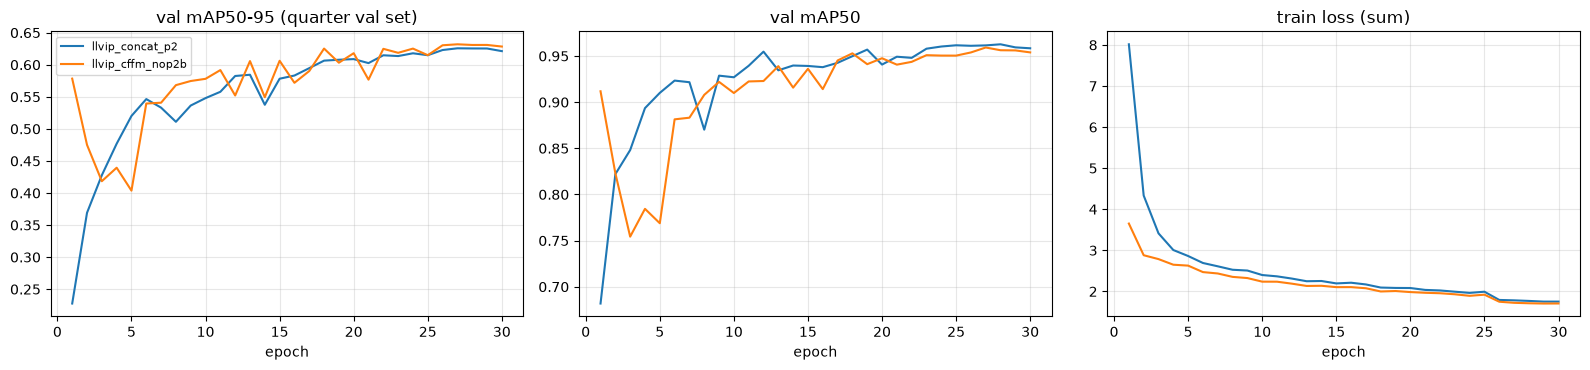

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for s in specs:
    f = env.runs / s["name"] / "results.csv"
    if not f.exists():
        continue
    df = pd.read_csv(f)
    df.columns = [c.strip() for c in df.columns]
    axes[0].plot(df["epoch"], df["metrics/mAP50-95(B)"], label=s["name"])
    axes[1].plot(df["epoch"], df["metrics/mAP50(B)"], label=s["name"])
    loss_cols = [c for c in df.columns if c.startswith("train/") and c.endswith("loss")]
    axes[2].plot(df["epoch"], df[loss_cols].sum(axis=1), label=s["name"])
for a, t in zip(axes, ["val mAP50-95 (quarter val set)", "val mAP50", "train loss (sum)"]):
    a.set_title(t); a.set_xlabel("epoch"); a.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Results on the full validation set

In [5]:
import pandas as pd
keys = ["mAP50-95(B)", "mAP50(B)", "mAP_small(B)", "AP_vt(B)", "AP_t(B)", "AP_s(B)", "AP_m(B)", "AP_l(B)"]
rows = [{"run": r["run"], **{k.replace("(B)", ""): r["metrics"].get(k) for k in keys}} for r in results]
pd.DataFrame(rows).set_index("run").round(4)

,mAP50-95,mAP50,mAP_small,AP_vt,AP_t,AP_s,AP_m,AP_l
run,,,,,,,,
llvip_concat_p2,0.6321,0.9622,0.0556,NaN,NaN,0.0557,0.6294,0.6595
llvip_cffm_nop2b,0.6350,0.9604,0.0750,NaN,NaN,0.0750,0.6333,0.6493


In [6]:
if env.platform == "kaggle":
    shutil.rmtree(env.data, ignore_errors=True)

### Keep the results

On Kaggle, click **Save Version → Save & Run All (Commit)** so `runs/` becomes an output that notebooks **09**
and **15** can attach (*Add Input → Your Work → this notebook*). Without a saved version the checkpoints vanish.